# Aircraft Engine Predictive Maintainance

## Feature Engineering Notebook - NASA C-MAPSS FD001
---
**Purpose**: Transform raw sensor readings to rich, model friendly matrix. Every feature is motivated by domain knowledge and EDA findings from the companion EDA Notebook.

## 1. Setup & Raw Data Loading

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f8f9fa',
                     'font.size':11,'axes.titlesize':12,'axes.titleweight':'bold'})

SENSOR_COLS  = [f'sensor_{i}' for i in range(1, 22)]
OP_COLS      = ['op_set_1', 'op_set_2', 'op_set_3']
ALL_COLS     = ['engine_id', 'cycle'] + OP_COLS + SENSOR_COLS

train_raw = pd.read_csv(r'data/raw/train_FD001.txt', sep=r'\s+', header=None, names=ALL_COLS)
test_raw  = pd.read_csv(r'data/raw/test_FD001.txt',  sep=r'\s+', header=None, names=ALL_COLS)
rul_true  = pd.read_csv(r'data/raw/RUL_FD001.txt',  header=None, names=['RUL'])

last_cycle_test = test_raw.groupby('engine_id')['cycle'].max().reset_index()
last_cycle_test.columns = ['engine_id', 'last_cycle']
rul_true['engine_id'] = range(1, 101)

print(f'Train shape : {train_raw.shape}')
print(f'Test shape  : {test_raw.shape}')
print(f'RUL labels  : {rul_true.shape}')
print()
print('Train engines :', train_raw['engine_id'].nunique())
print('Test engines  :', test_raw['engine_id'].nunique())
train_raw.head(3)

Train shape : (20631, 26)
Test shape  : (13096, 26)
RUL labels  : (100, 2)

Train engines : 100
Test engines  : 100


,engine_id,cycle,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


---
## 2. Drop Zero-Variance / Constant Features

In [91]:
def feature_variablity(df, cols):
    stats_df = df[cols].agg(['std','mean','min','max'])
    result = pd.DataFrame({
        'std' : stats_df.loc['std'],
        'mean' : stats_df.loc['mean'],
        'range' : stats_df.loc['max'] - stats_df.loc['min']
    })

    result['cv_pct'] = (result['std'] / result['mean'].abs() * 100).round(3)        # Variablity of data relative to mean

    return result.sort_values('std')

var_report = feature_variablity(train_raw, SENSOR_COLS + OP_COLS)

# DROP_MASK = (var_report['std'] < 0.02) | (var_report['range'] < 0.5)
DROP_MASK = (var_report['std'] < 0.02) & (var_report['range'] < 0.5)
DROP_COLS = var_report[DROP_MASK].index.tolist()
KEEP_SENSORS = [c for c in (SENSOR_COLS + OP_COLS) if c not in DROP_COLS]

print('ZERO/NEAR-ZERO VARIANCE FEATURES')
print('=' * 55)
print(var_report[DROP_MASK][['std','range','cv_pct']].to_string())
print()
print(f'Features Dropped: {len(DROP_COLS)} -> {DROP_COLS}')
print(f'Fetures Kept: {len(KEEP_SENSORS)} -> {KEEP_SENSORS}')

ZERO/NEAR-ZERO VARIANCE FEATURES
                    std   range     cv_pct
sensor_1   0.000000e+00  0.0000      0.000
sensor_10  0.000000e+00  0.0000      0.000
sensor_19  0.000000e+00  0.0000      0.000
sensor_18  0.000000e+00  0.0000      0.000
op_set_3   0.000000e+00  0.0000      0.000
sensor_16  3.469531e-18  0.0000      0.000
sensor_5   5.329200e-15  0.0000      0.000
op_set_2   2.930621e-04  0.0012  12466.319
sensor_6   1.388985e-03  0.0100      0.006
op_set_1   2.187313e-03  0.0174  24659.270

Features Dropped: 10 -> ['sensor_1', 'sensor_10', 'sensor_19', 'sensor_18', 'op_set_3', 'sensor_16', 'sensor_5', 'op_set_2', 'sensor_6', 'op_set_1']
Fetures Kept: 14 -> ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


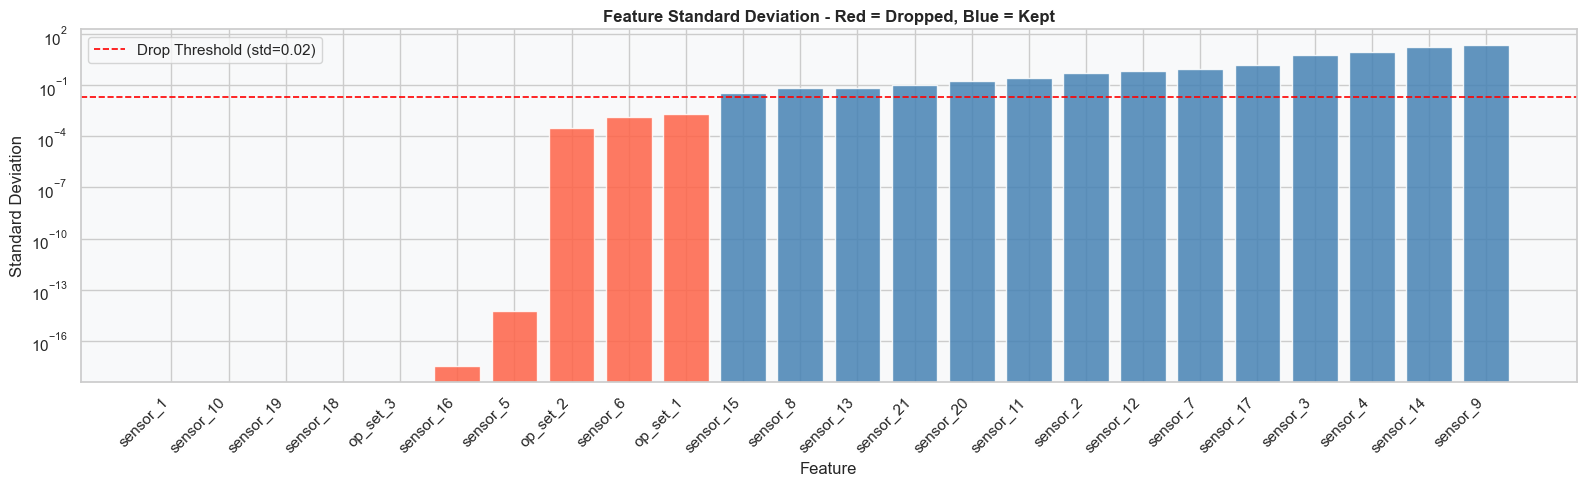

In [92]:
fig, ax = plt.subplots(figsize=(16,5))
colors = ['tomato' if c in DROP_COLS else 'steelblue' for c in var_report.index]

ax.bar(var_report.index, var_report['std'], color=colors, alpha=0.85, edgecolor='white')
ax.axhline(0.02, color='red', linestyle='--', linewidth=1.2, label='Drop Threshold (std=0.02)')
ax.set_title('Feature Standard Deviation - Red = Dropped, Blue = Kept')
ax.set_xlabel('Feature')
ax.set_ylabel('Standard Deviation')
ax.set_yscale('log')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

In [93]:
train_v2 = train_raw.drop(columns=DROP_COLS)
test_v2 = test_raw.drop(columns=DROP_COLS)

print(f'Training Data after drop: {train_v2.shape}')
print(f'Testing Data after drop: {test_v2.shape}')

Training Data after drop: (20631, 16)
Testing Data after drop: (13096, 16)


### Key Findings

10 features were dropped for near-zero variance - **sensor_1, sensor_5, sensor_6, sensor_10, sensor_16, sensor_18, sensor_19**, and all three **op_set** columns - exactly matching the EDA's "Removable" sensor list. This takes the working feature set from 26 columns down to 16 (14 sensors + `engine_id`/`cycle`), removing noise before any further engineering begins rather than carrying dead weight through every downstream step.


---
## 3. RUL Target Engineering

**EDA Finding**: Raw RUL = max_cycle - cycle is linear by construction and forces the model to distinguish between RUL=350 and RUL=300 - two states that look identical from sensor readings.
We engineer two improved targets:
- **Capped RUL (primary)**: min(raw_RUL, RUL_CAP) - piecewise linear, focuses learning on degradation zone.
- **Log RUL (secondary)**: log(capped_URL + 1) - compresses the high-RUL tail, useful for Regression stability.

The cap of 125 is choosen based on the EDA observation that the most informative degradation patterns emerge in the last ~125 cycles of engine life.

In [94]:
RUL_CAP = 125

max_cyc_train = train_v2.groupby('engine_id')['cycle'].transform('max')
train_v2['RUL_raw'] = max_cyc_train - train_v2['cycle']
train_v2['RUL_capped'] = np.minimum(train_v2['RUL_raw'], RUL_CAP)
train_v2['RUL_log'] = np.log1p(train_v2['RUL_capped'])

rul_true['RUL_capped'] = np.minimum(rul_true['RUL'], RUL_CAP)

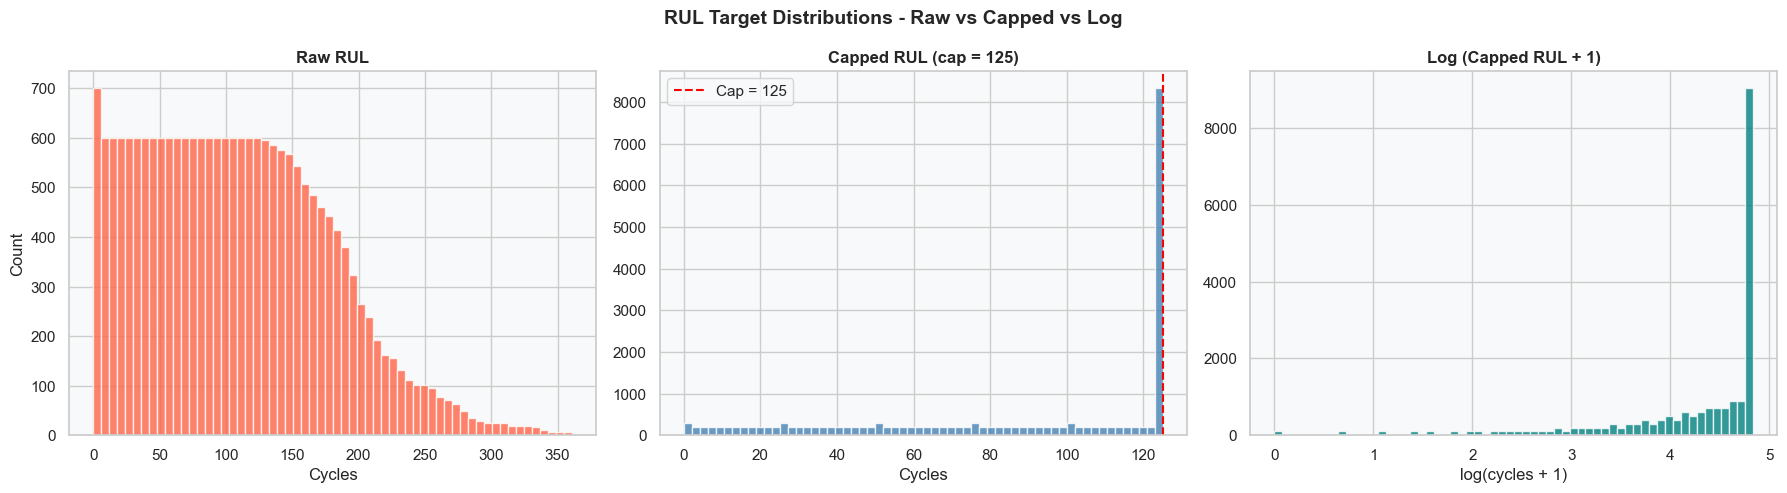

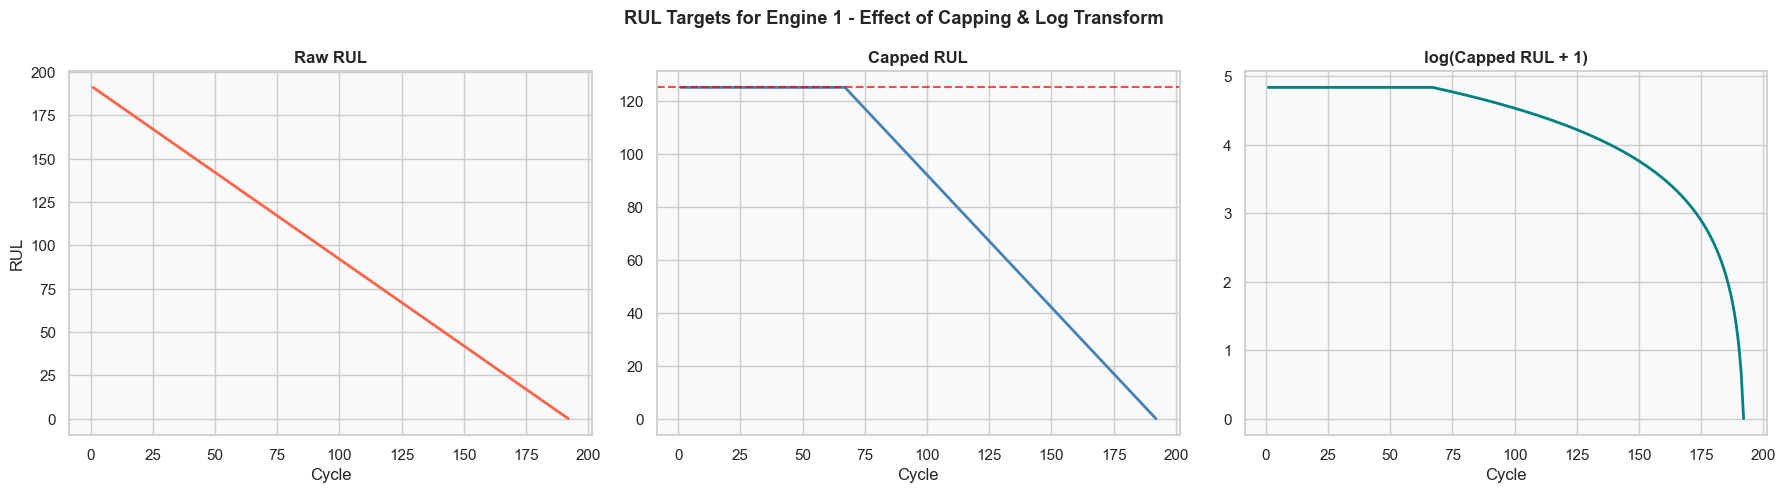

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RUL Target Distributions - Raw vs Capped vs Log', fontsize=14, fontweight='bold')

axes[0].hist(train_v2['RUL_raw'], bins=60, color='tomato', edgecolor='white', alpha=0.8)
axes[0].set_title('Raw RUL')
axes[0].set_xlabel('Cycles')
axes[0].set_ylabel('Count')

axes[1].hist(train_v2['RUL_capped'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(RUL_CAP, color='red', linestyle='--', label=f'Cap = {RUL_CAP}')
axes[1].set_title(f'Capped RUL (cap = {RUL_CAP})')
axes[1].set_xlabel('Cycles')
axes[1].legend()

axes[2].hist(train_v2['RUL_log'], bins=60, color='teal', edgecolor='white', alpha=0.8)
axes[2].set_title('Log (Capped RUL + 1)')
axes[2].set_xlabel('log(cycles + 1)')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RUL Targets for Engine 1 - Effect of Capping & Log Transform', fontweight='bold')

e1 = train_v2[train_v2['engine_id'] == 1]

axes[0].plot(e1['cycle'], e1['RUL_raw'], color='tomato', linewidth=2)
axes[0].set_title('Raw RUL')
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('RUL')

axes[1].plot(e1['cycle'], e1['RUL_capped'], color='steelblue', linewidth=2)
axes[1].axhline(RUL_CAP, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Capped RUL')
axes[1].set_xlabel('Cycle')

axes[2].plot(e1['cycle'], e1['RUL_log'], color='teal', linewidth=2)
axes[2].set_title('log(Capped RUL + 1)')
axes[2].set_xlabel('Cycle')

plt.tight_layout()
plt.show()

### Key Observations

- **Raw RUL** is unbounded and right-skewed exactly as seen in the EDA, with engines reaching 350+ cycles before failure.
- **Capped RUL** flattens the long tail at 125 cycles, turning the early-life plateau into a constant value and concentrating the label's information in the degradation zone.
- **Log RUL** further compresses the upper range, which should help a neural network's MSE loss avoid being dominated by the (now-capped) early-life cycles.

For Engine 1 specifically, the per-cycle line plots make the construction explicit: raw RUL falls linearly to zero, capped RUL is flat-then-falling, and log RUL curves the falling segment instead of keeping it linear.


---
## 4. Engine Normalization

In [ ]:
def normalize_data(df, cols, scaler, fit=False):
    df = df.copy()

    if fit:
        normed = scaler.fit_transform(df[cols])
    else:
        normed = scaler.transform(df[cols])
    
    normed = pd.DataFrame(normed, columns=[f'{col}_norm' for col in cols], index=df.index)

    return normed

FEAT_COLS = [c for c in KEEP_SENSORS if c != 'op_set_3']

scaler = MinMaxScaler()
normed_train = normalize_data(train_v2, FEAT_COLS, scaler, fit=True)
train_v3 = pd.concat([train_v2, normed_train], axis=1)

NORM_COLS = [c + '_norm' for c in FEAT_COLS]

print(f'Normalised columns added: {len(NORM_COLS)}')
print('Sample normalised ranges (should all be [0, 1]):')
print(train_v3[NORM_COLS].agg(['min','max']).T.head(8).to_string())

Normalised columns added: 14
Sample normalised ranges (should all be [0, 1]):
                min  max
sensor_2_norm   0.0  1.0
sensor_3_norm   0.0  1.0
sensor_4_norm   0.0  1.0
sensor_7_norm   0.0  1.0
sensor_8_norm   0.0  1.0
sensor_9_norm   0.0  1.0
sensor_11_norm  0.0  1.0
sensor_12_norm  0.0  1.0


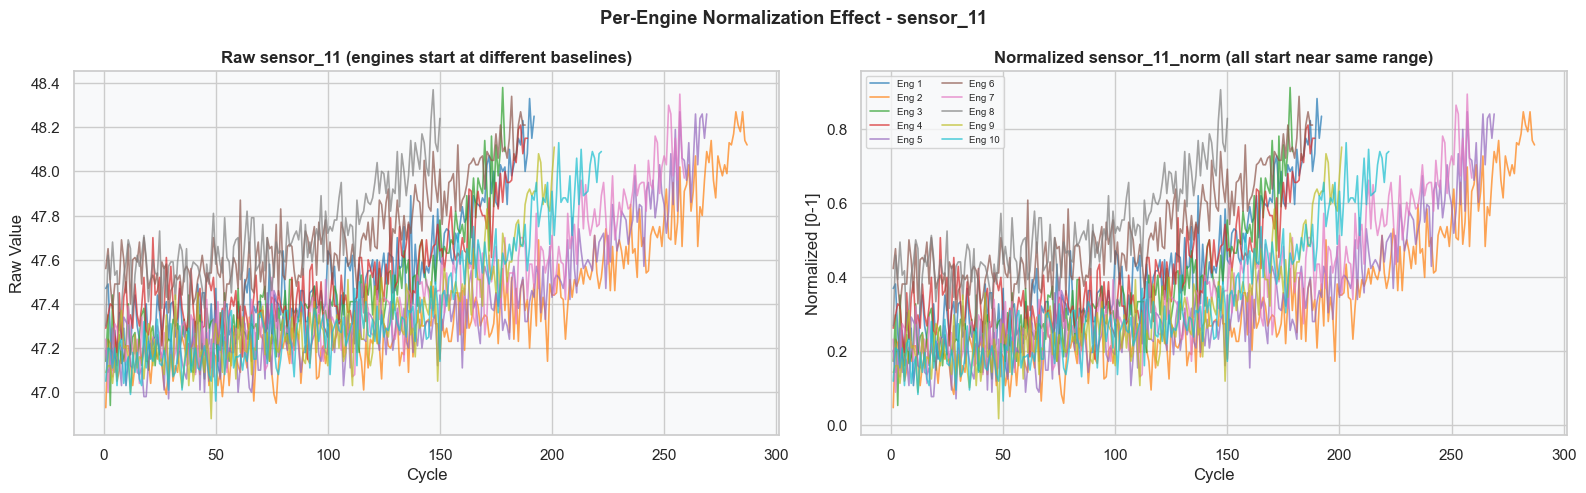

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Per-Engine Normalization Effect - sensor_11', fontweight='bold')

palette = sns.color_palette('tab10',10)

for j, eid in enumerate(range(1, 11)):
    sub = train_v3[train_v3['engine_id'] == eid]
    axes[0].plot(sub['cycle'], sub['sensor_11'], color=palette[j], alpha=0.7, linewidth=1.2)
    axes[1].plot(sub['cycle'], sub['sensor_11_norm'], color=palette[j], alpha=0.7, linewidth=1.2, label=f'Eng {eid}')

axes[0].set_title('Raw sensor_11 (engines start at different baselines)')
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Raw Value')

axes[1].set_title('Normalized sensor_11_norm (all start near same range)')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('Normalized [0-1]')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

### Key Observations

Before Normalization, engines start at measurably different baseline values - a manufacturing noise artefact. After per engine normalization, the starting distribution is tightened and the degradation trend is visible as a consistent directional movement toward 0 or 1.

---

## 5. Rolling Window Features (Std)
**EDA Finding**: Raw sensors readings are noisy. The underlying degradation trend is only visible after smoothing. Rolling Statistics provide the model with:
- **Rolling Std**: local volatility - increases near failure as sensors become unstable.

**Window of 30 cycles** used to capture medium dynamics.

In [99]:
def add_rolling_features(df, feature_cols, window=15):
    df = df.sort_values(['engine_id','cycle']).copy()
    new_cols = {}

    for col in feature_cols:
        grp = df.groupby('engine_id')[col]
        roll = grp.rolling(window=window, min_periods=1)

        new_cols[f'{col}_rstd_{window}'] = roll.std().fillna(0).reset_index(level=0, drop=True)
    
    return pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

print('Computing Rolling Features on Normalized Columns:')
train_v4 = add_rolling_features(train_v3, NORM_COLS)

roll_cols = [c for c in train_v4.columns if '_rstd_15' in c]

print(f'Rolling Features added: {len(roll_cols)}')
print(f'Total Columns so far: {train_v4.shape[1]}')

Computing Rolling Features on Normalized Columns:
Rolling Features added: 14
Total Columns so far: 47


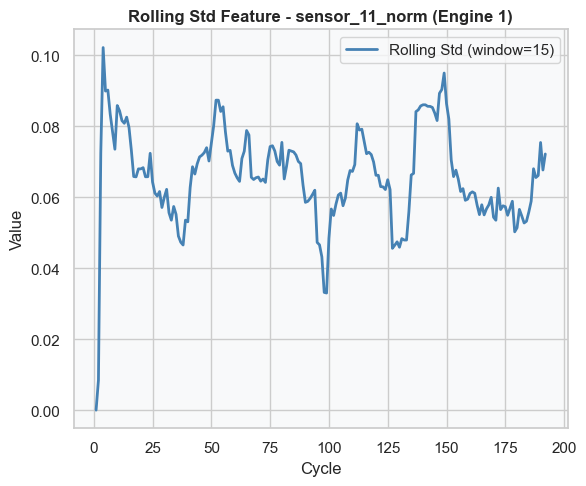

In [100]:
fig, ax = plt.subplots(figsize=(6, 5))

e1 = train_v4[train_v4['engine_id'] == 1]

ax.plot(e1['cycle'], e1['sensor_11_norm_rstd_15'], color='steelblue', linewidth=2, label='Rolling Std (window=15)')

ax.set_title('Rolling Std Feature - sensor_11_norm (Engine 1)', fontweight='bold')
ax.set_xlabel('Cycle')
ax.set_ylabel('Value')
ax.legend()

plt.tight_layout()
plt.show()

---
## 6. Delta Features

A delta feature captures **short-term change**, independent of the absolute level a sensor happens to be at: `value[t] - value[t - lag]`. Where the rolling-std feature (above) measures *volatility*, a delta feature measures *directional movement* over a fixed lag - useful since several sensors trend consistently in one direction as the engine degrades.


In [101]:
def add_delta_features(df, feature_cols, lag=3):
    df = df.sort_values(['engine_id','cycle']).copy()
    new_cols = {}

    for col in feature_cols:
        shifted = df.groupby('engine_id')[col].shift(lag)
        shifted = shifted.groupby(df['engine_id']).transform(lambda x: x.bfill())

        new_cols[f'{col}_delta{lag}'] = df[col] - shifted

    return pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

KEY_SENSORS_NORM = [f'{col}_norm' for col in KEEP_SENSORS]
train_v5 = add_delta_features(train_v4, KEY_SENSORS_NORM)

delta_cols = [c for c in train_v5.columns if '_delta' in c]
print(f'Delta features added: {len(delta_cols)}')

Delta features added: 14


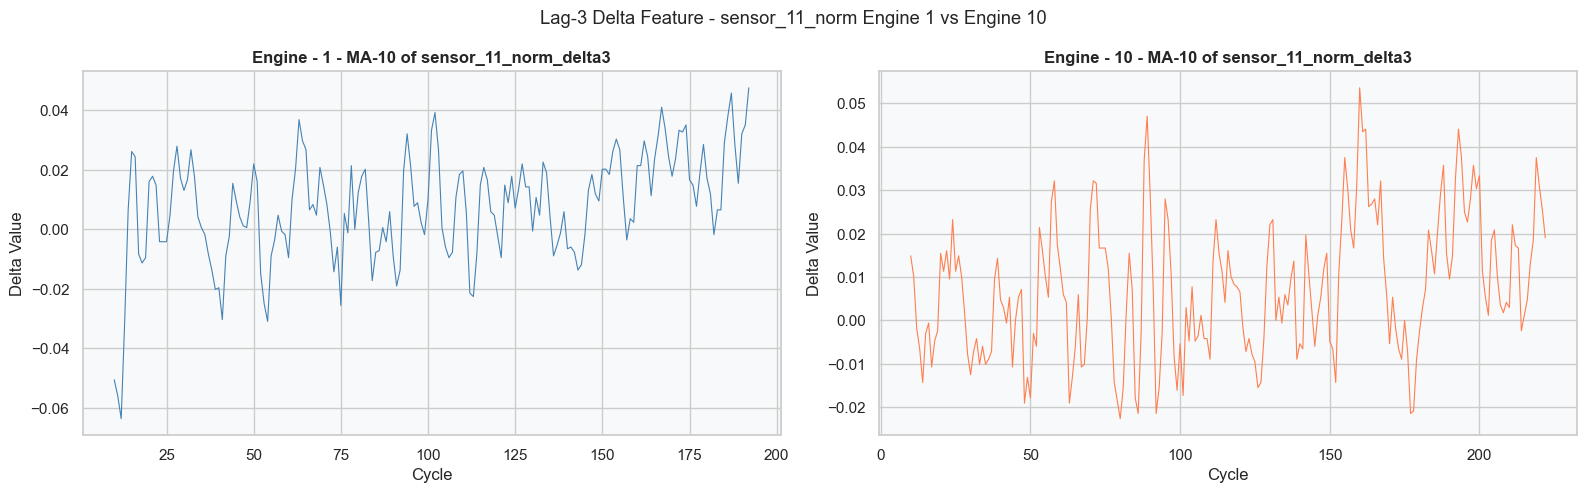

In [102]:
lag = 3
delta_col = f'sensor_11_norm_delta{lag}'

fig, axes = plt.subplots(1, 2, figsize=(16,5))
fig.suptitle(f'Lag-{lag} Delta Feature - sensor_11_norm Engine 1 vs Engine 10')

for ax, eid, color in zip(axes, [1, 10], ['steelblue','coral']):
    sub = train_v5[train_v5['engine_id'] == eid]

    ax.plot(sub['cycle'], sub[delta_col].rolling(10).mean(), color=color, linewidth=0.8)
    ax.set_title(f'Engine - {eid} - MA-10 of {delta_col}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Delta Value')

plt.tight_layout()
plt.show()

#### Key Observations

The lag-3 delta signal is noisy at the per-cycle level but, once smoothed with a moving average, shows a visible drift away from zero as engines age - confirming the directional-movement features carry the kind of signal the rolling-std features alone don't capture.


---
## 7. Trend/Slope Features

Rolling mean tells us the level of a sensor. Slope tells us the direction and speed of change. We fit a simple linear regression over a rolling window and extract the slope coefficient. A steep negative slope on sensor_7 (which decreases toward failure) is a strong RUL signal.

In [103]:
def rolling_slope(series, window=20):
    n = len(series)
    slopes = np.full(n, np.nan)
    vals = series.values
    x = np.arange(window, dtype=float)
    x_mean = x.mean()
    x_var = ((x - x_mean) ** 2).sum()

    for i in range(window-1, n):
        y = vals[i - window + 1 : i + 1]
        slopes[i] = np.dot(x - x_mean, y - y.mean()) / x_var
    
    first_valid = next((i for i, v in enumerate(slopes) if not np.isnan(v)), 0)
    slopes[:first_valid] = slopes[first_valid] if first_valid < n else 0.0

    return pd.Series(slopes, index=series.index)

def add_slope_features(df, feature_cols, window=20):
    df = df.sort_values(['engine_id','cycle']).copy()
    new_cols = {}

    for col in feature_cols:
        key = f'{col}_slope{window}'
        new_cols[key] = df.groupby('engine_id')[col].transform(lambda s: rolling_slope(s, window))
    
    return pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

print('Computing Slope-based features:')
train_v6 = add_slope_features(train_v5, KEY_SENSORS_NORM)

slope_cols = [c for c in train_v6.columns if '_slope' in c]

print(f'Slope features added : {len(slope_cols)}')
print(f'Total columns so far : {train_v6.shape[1]}')

Computing Slope-based features:
Slope features added : 14
Total columns so far : 75


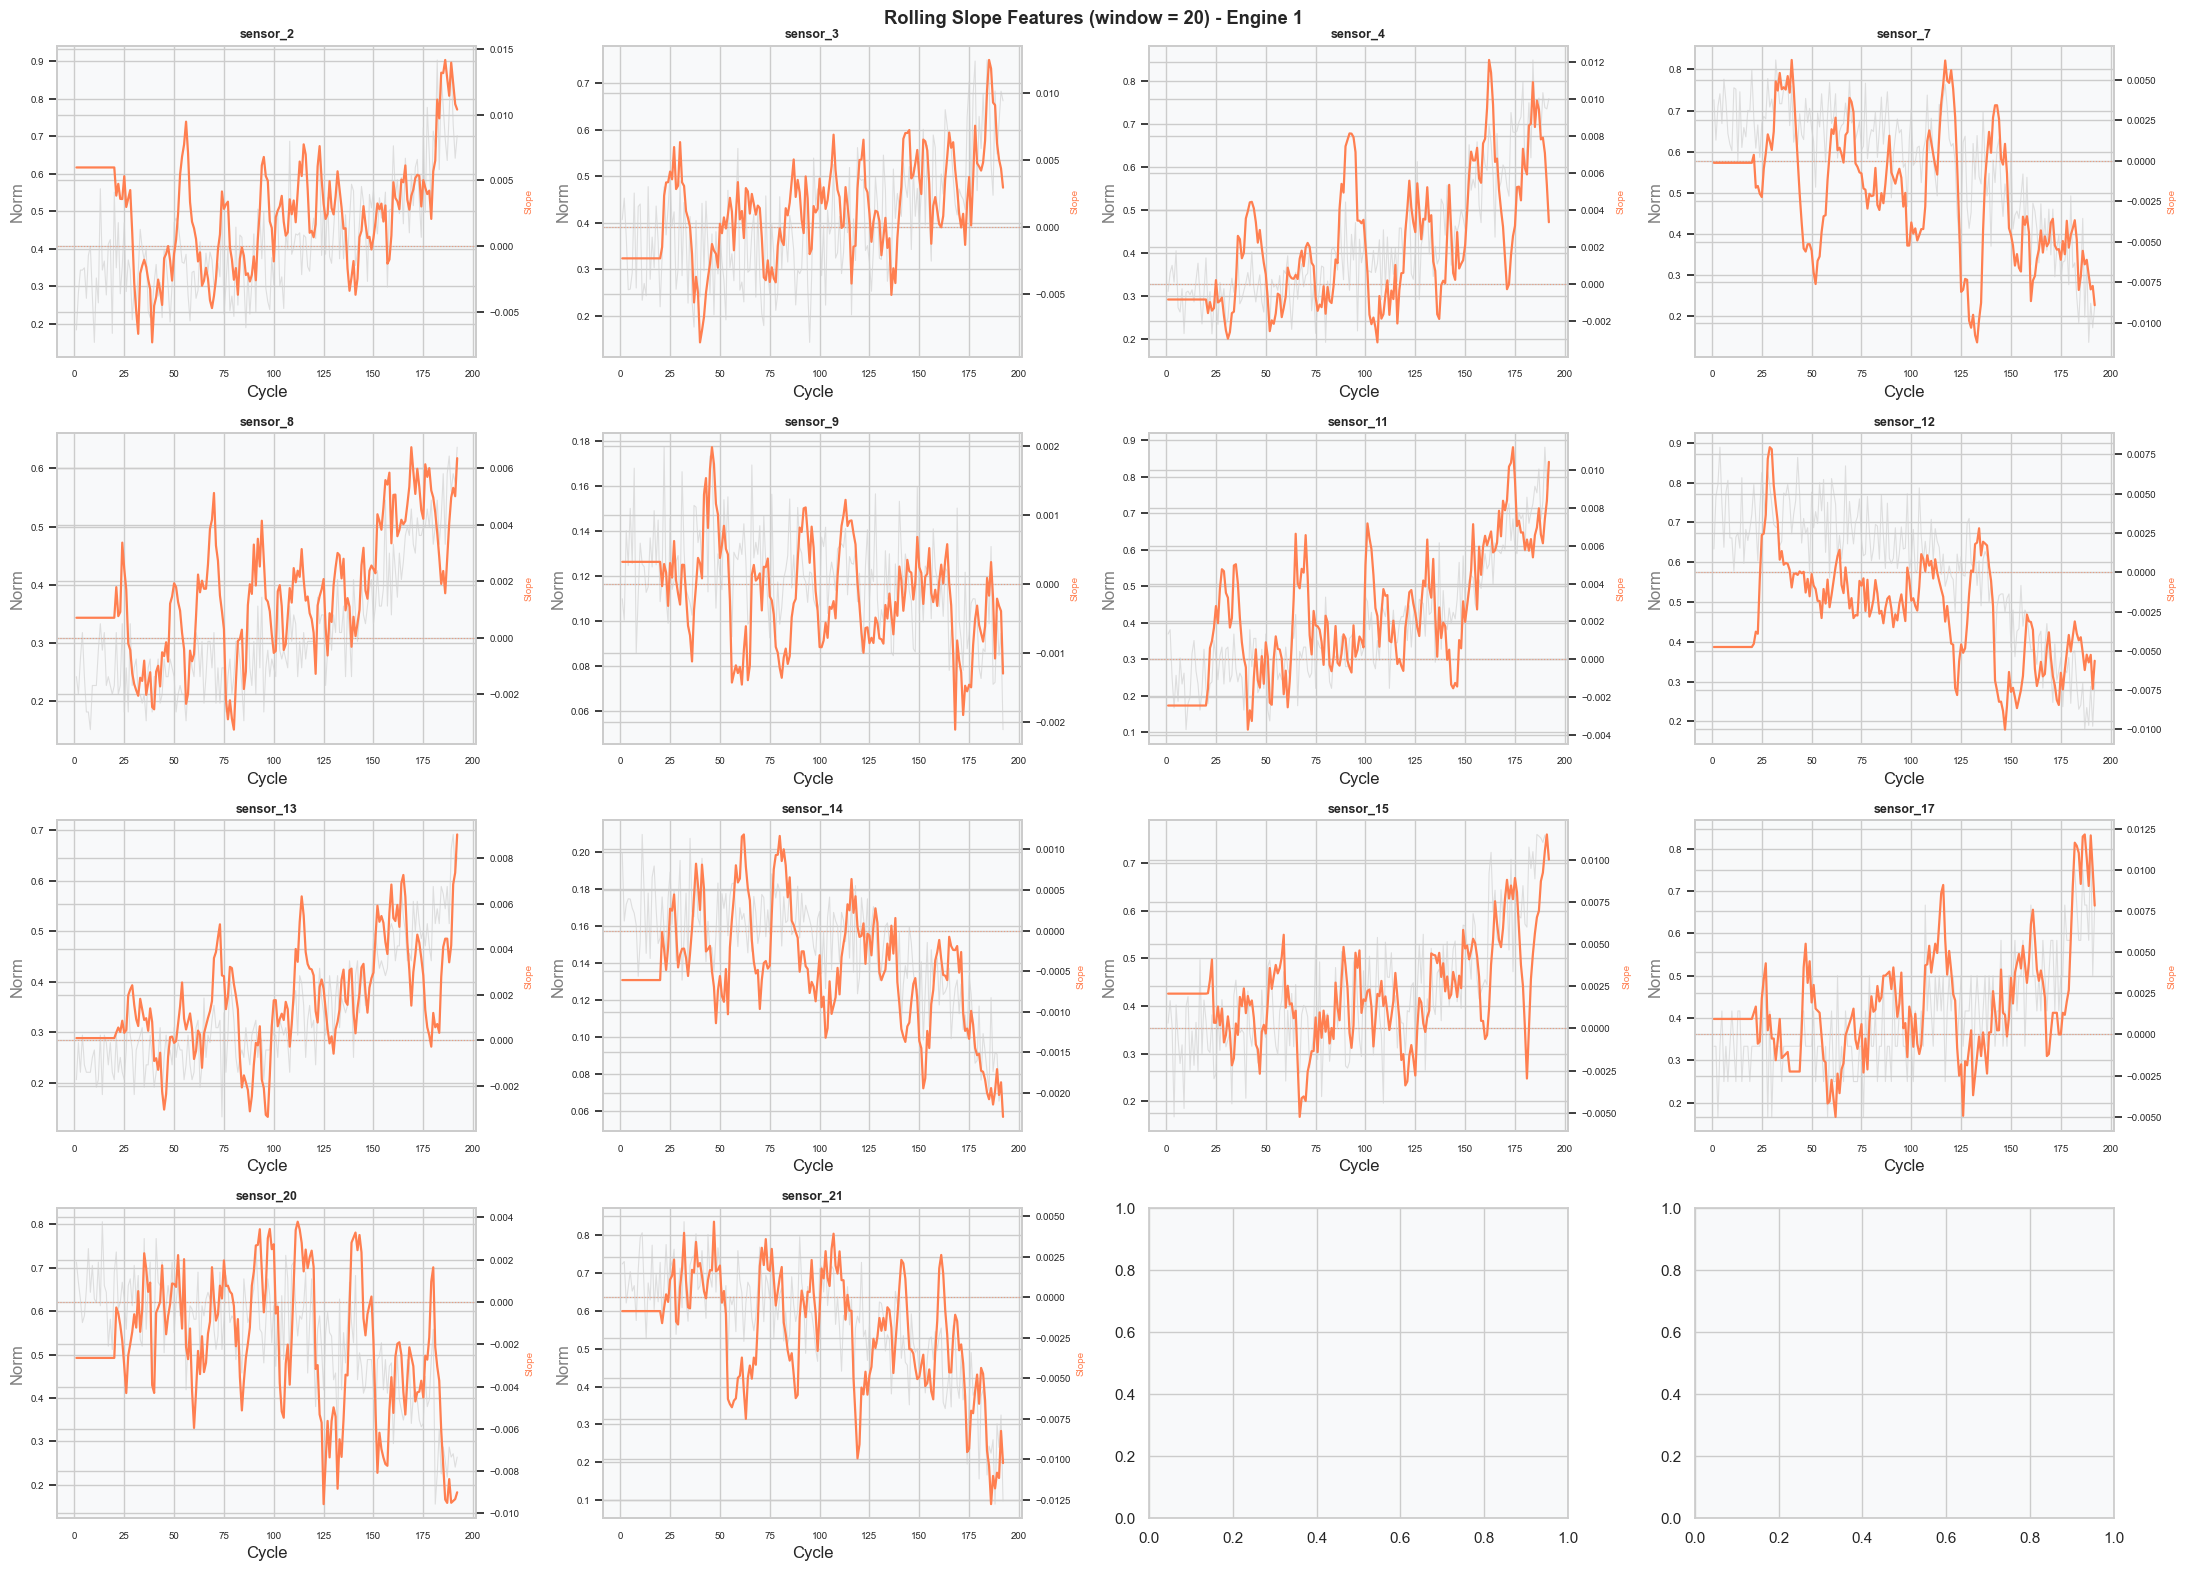

In [104]:
import math
window = 20

n = len(KEY_SENSORS_NORM)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 4 * nrows))
fig.suptitle(f'Rolling Slope Features (window = {window}) - Engine 1', fontweight='bold')

axes = axes.flatten()

e1 = train_v6[train_v6['engine_id'] == 1]

for i, col in enumerate(KEY_SENSORS_NORM):
    slope_col = f'{col}_slope{window}'

    twin = axes[i].twinx()

    axes[i].plot(e1['cycle'], e1[col], color='lightgray', linewidth=0.8, alpha=0.7)
    twin.plot(e1['cycle'], e1[slope_col], color='coral', linewidth=1.6)
    twin.axhline(0, color='coral', linestyle=':', linewidth=0.8, alpha=0.6)

    axes[i].set_title(col.replace('_norm',''), fontsize=9)
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Norm', color='gray')
    twin.set_ylabel('Slope', fontsize=7, color='coral')

    axes[i].tick_params(labelsize=7)
    twin.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

---
## 8. Cycle-Position Features

The EDA showed that degradation is not just about sensor level but also about where in the lifecycle the engine is. Two explicit features encode temporal position:

In [105]:
def add_cycle_features(df):
    df = df.sort_values(['engine_id','cycle']).copy()

    df['cycle_count'] = df['cycle']
    
    return df

train_v7 = add_cycle_features(train_v6)

cycle_feat_cols = ['cycle_count']
print('Cycle-position features added:', cycle_feat_cols)

Cycle-position features added: ['cycle_count']


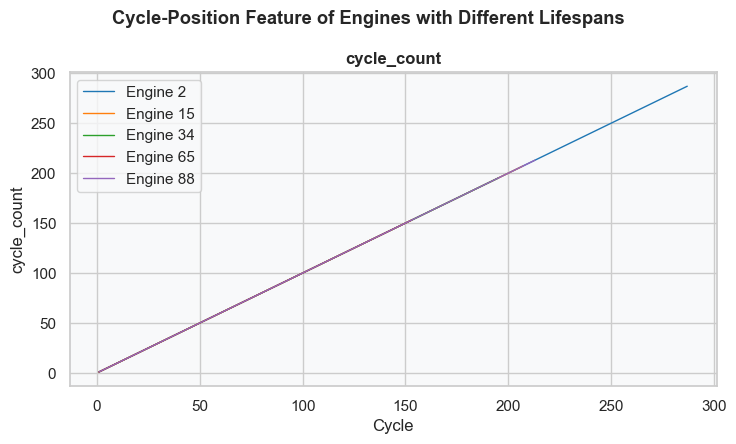

In [106]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
fig.suptitle('Cycle-Position Feature of Engines with Different Lifespans', fontweight='bold')

sample_eids = [2, 15, 34, 65, 88]
colors = sns.color_palette(palette='tab10',n_colors=len(sample_eids))

for eid, color in zip(sample_eids, colors):
    sub = train_v7[train_v7['engine_id'] == eid]

    ax.plot(sub['cycle'], sub['cycle_count'], color=color, linewidth=1, label=f'Engine {eid}')
    ax.set_title('cycle_count')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('cycle_count')
    ax.legend()

plt.tight_layout()
plt.show()

---
## 9. Health Index - Composite Degradation Score

Individual Sensors are noisy and may temporarily move opposite to the degradation direction. A Health Index (HI)  aggregates the signal from the multiple sensors into a single score that is more robust than any individual sensor.

**Construction**:
1. Identify Sensors with consisten degradation direction (from EDA monotonocity analysis).
2. Flip sensors that decrease toward failure so that all point in the same direction.
3. Average the normalized, direction-corrected sensors into a signal HI in [0, 1].
    - HI near 0 = near failure
    - HI near 1 = near healthy

In [107]:
# Sensors that increase as Engine degrades (failure = high value)
DEGRADE_UP   = ['sensor_4_norm','sensor_11_norm','sensor_12_norm','sensor_15_norm','sensor_20_norm','sensor_21_norm']

# Sensors that decrease as Engine degrades (failure = low value)
DEGRADE_DOWN = ['sensor_2_norm','sensor_3_norm','sensor_7_norm','sensor_8_norm','sensor_9_norm','sensor_13_norm','sensor_14_norm','sensor_17_norm']

def add_health_index(df, degrade_up, degrade_down):
    df = df.copy()
    up_contributions = 1.0 - df[degrade_up]
    down_contributions = df[degrade_down]

    all_contributions = pd.concat([up_contributions, down_contributions], axis=1)
    df['health_index'] = 1 - all_contributions.mean(axis=1)

    return df

train_v8 = add_health_index(train_v7, DEGRADE_UP, DEGRADE_DOWN)
print('Health Index columns added: health_index')
print()
print('Health Index statistics:')
print(train_v8['health_index'].describe().round(3).to_string())

Health Index columns added: health_index

Health Index statistics:
count    20631.000
mean         0.576
std          0.035
min          0.310
25%          0.556
50%          0.580
75%          0.600
max          0.683


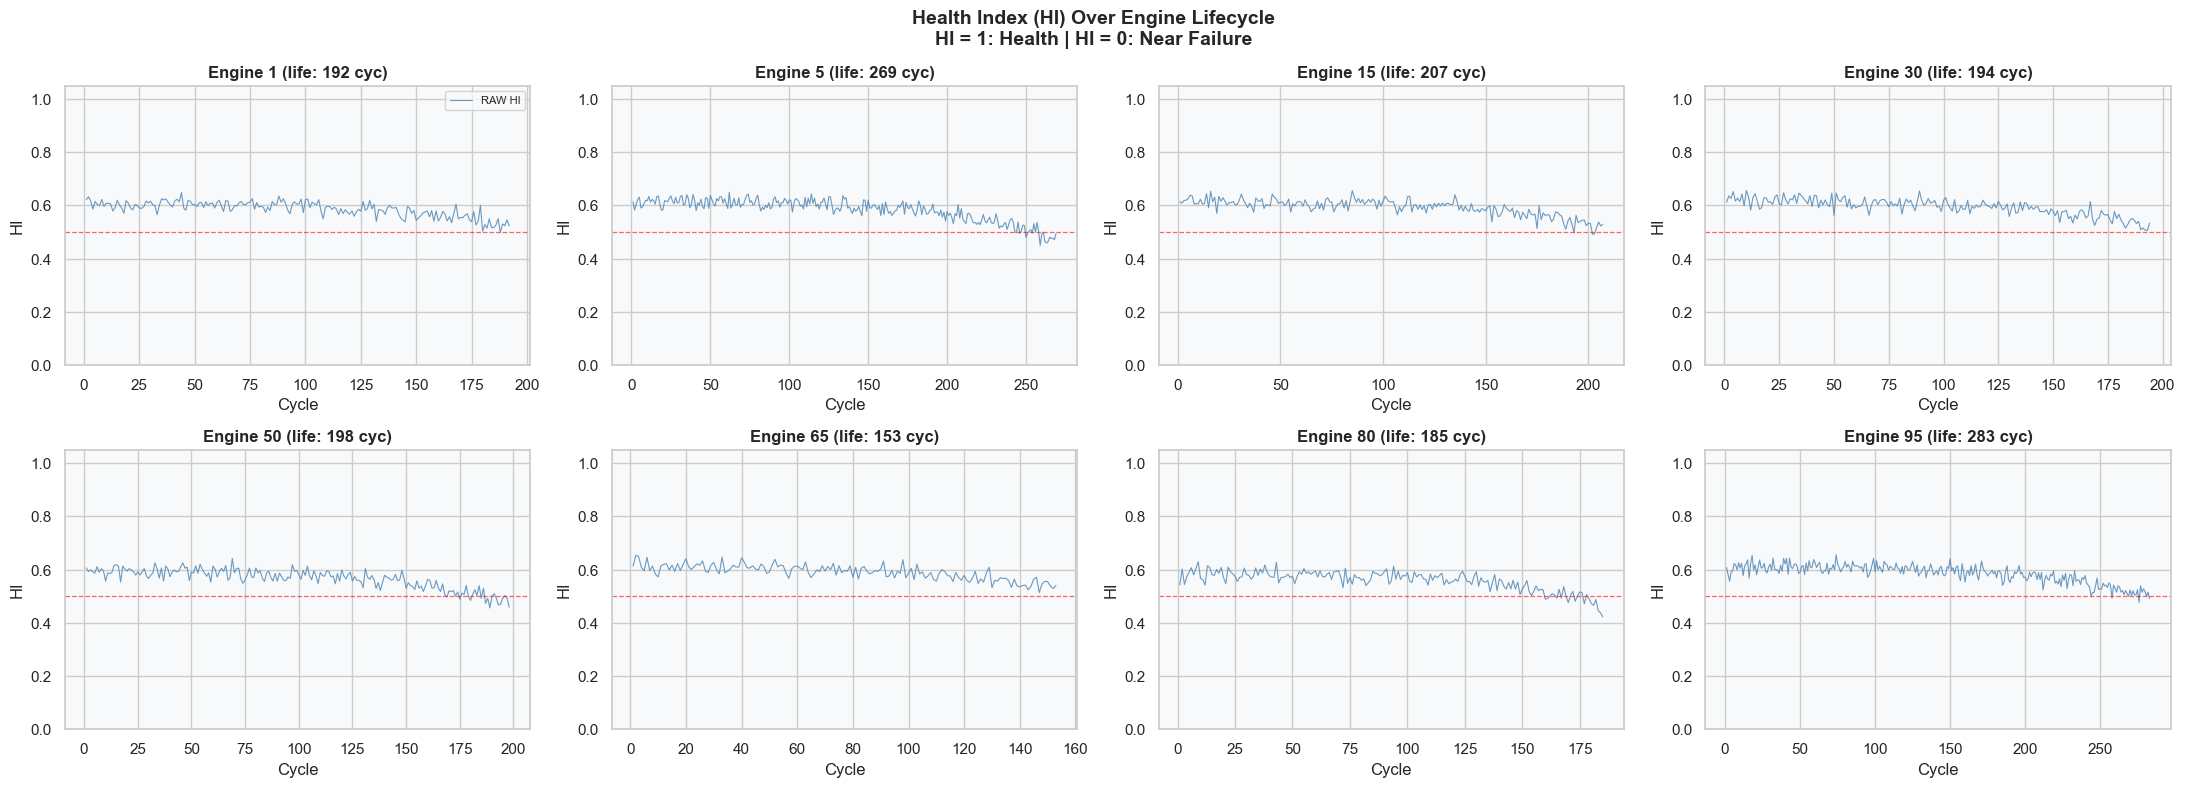

Correlation of Health Index with Capped RUL:
health_index    0.7413


In [108]:
sample_eids = [1, 5, 15, 30, 50, 65, 80, 95]
palette = sns.color_palette('tab10',8)

fig, axes = plt.subplots(2, 4, figsize=(22, 8))
fig.suptitle('Health Index (HI) Over Engine Lifecycle\nHI = 1: Health | HI = 0: Near Failure', fontsize=14, fontweight='bold')
axes = axes.flatten()

for j, eid in enumerate(sample_eids):
    sub = train_v8[train_v8['engine_id'] == eid]
    axes[j].plot(sub['cycle'], sub['health_index'], color='steelblue', linewidth=0.8, alpha=0.8, label='RAW HI')
    axes[j].axhline(0.5, color='red', linestyle='--', linewidth=0.9, alpha=0.6)
    axes[j].set_ylim(0, 1.05)
    axes[j].set_title(f'Engine {eid} (life: {sub["cycle"].max()} cyc)')
    axes[j].set_xlabel('Cycle')
    axes[j].set_ylabel('HI')
    if j == 0:
        axes[j].legend(fontsize=8)

plt.tight_layout()
plt.show()

corr_hi_rul = train_v8[['health_index','RUL_capped']].corr()
print('Correlation of Health Index with Capped RUL:')
print(corr_hi_rul['RUL_capped'].drop('RUL_capped').round(4).to_string())

#### Key Observations
- Health Index consistently trends near **1.0 toward 0.5-0.6** as engines apprach failure.
- Strong positive correlation with RUL confirms HI captures the degradation trajectory.

#### Business Interpretation
The Health Index is a single, interpretable score a maintainance engineer can monitor. "Engine 34 is at HI=0.55 and falling at 0.003/cycle - schedule maintainance in ~18 cycles. It is also an excellent standalone feature for dashboard 

#### Modelling Relevance
The HI is a **dimensionality reduction** of 14 sensors into 1 signal. It can be used as a primary feature of a simple model or as an additional feature alongside raw sensors for complex models.

## 10. Statistical Deviation from Engine Baseline

Per-engine normalization removes the initial offset but does not explicitly encode "how far the sensor moved from where it started?" Baseline Deviation features answer exactly this question:
- **abs_dev**: (current - first_cycle_value) - absolute drift from engine's own baseline.
- **z_score**: ((current - engine_mean) / engine_std) - standardized position in the engine's own distribution

These features are complementary to normalization and often highly predictive because they directly measure cumulative degradation regardless of operating point.

In [109]:
def add_baseline_deviations(df, feature_cols):
    df = df.sort_values(['engine_id','cycle']).copy()
    new_cols = {}

    eng_first = df.groupby('engine_id')[feature_cols].transform('first')

    for col in feature_cols:
        new_cols[f'{col}_absdev'] = (df[col] - eng_first[col]).abs()
    
    return pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

print('Computing baseline deviation features:')
train_v9 = add_baseline_deviations(train_v8, KEY_SENSORS_NORM)

dev_cols = [c for c in train_v9.columns if 'absdev' in c]
print(f'Deviation features added : {len(dev_cols)}')
print(f'Total columns so far     : {train_v9.shape[1]}')

Computing baseline deviation features:
Deviation features added : 14
Total columns so far     : 91


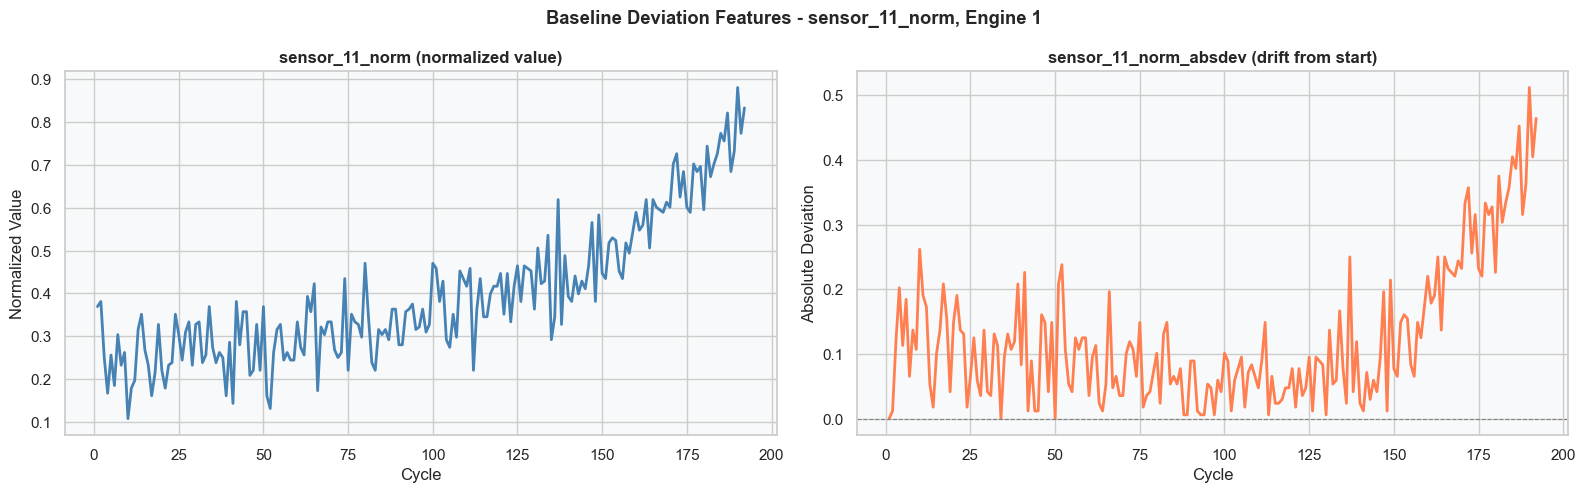

Top AbsDev correlations with Capped RUL:
sensor_11_norm_absdev    0.7518
sensor_12_norm_absdev    0.7018
sensor_4_norm_absdev     0.6827
sensor_7_norm_absdev     0.6723
sensor_15_norm_absdev    0.6216
sensor_21_norm_absdev    0.6048


In [110]:
fig, axes  = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Baseline Deviation Features - sensor_11_norm, Engine 1', fontweight='bold')

e1 = train_v9[train_v9['engine_id'] == 1]

axes[0].plot(e1['cycle'], e1['sensor_11_norm'], color='steelblue', linewidth=2)
axes[0].set_title('sensor_11_norm (normalized value)')
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Normalized Value')

axes[1].plot(e1['cycle'], e1['sensor_11_norm_absdev'], color='coral', linewidth=2)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('sensor_11_norm_absdev (drift from start)')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('Absolute Deviation')

plt.tight_layout()
plt.show()

absdev_cols = [c for c in dev_cols if '_absdev' in c]
zscore_vals = [c for c in dev_cols if '_zscore' in c]

corr_dev = [c for c in dev_cols if '_absdev' in c]
zscore_vals = [c for c in dev_cols if '_zscore' in c]

corr_dev = train_v9[absdev_cols + ['RUL_capped']].corr()['RUL_capped'].drop('RUL_capped')
print('Top AbsDev correlations with Capped RUL:')
print(corr_dev.abs().sort_values(ascending=False).head(6).round(4).to_string())

### Key Observations
- **absdev** features show a clear monotonic increase (or decrease) from zero as engine ages - a direct quantification of cumulative wear.
- **zscore** features normalize each engine's readings relative to its own lifetime distribution, making it late-life anomalies statistically explicit. 

---
## 11. Feature Quality Audit

In [111]:
EXCLUDE = ['engine_id','cycle','RUL_raw','RUL_capped','RUL_log']
EXCLUDE += FEAT_COLS
EXCLUDE += OP_COLS

ALL_FEATURE_COLS = [c for c in train_v9.columns if c not in EXCLUDE and not c.startswith('op_set')]

X_train_full = train_v9[ALL_FEATURE_COLS].copy()
y_train  = train_v9['RUL_capped'].copy()

print(f'Total candidate features: {len(ALL_FEATURE_COLS)}')
print()

Total candidate features: 72



In [112]:
corr_matrix = X_train_full.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.at[row, col]) for col in upper.columns for row in upper.index if pd.notna(upper.at[row, col]) and upper.at[row, col] > 0.80]

print(f'Highly correlated pairs (|r| > 0.80): {len(high_corr_pairs)}')
print('Top 10 most correlated pairs:')
sorted_pairs = sorted(high_corr_pairs, key=lambda x: -x[2])
for a, b, r in sorted_pairs[:15]:
    print(f'{a[:35]} <-> {b[:35]} : r={r:.4f}')

Highly correlated pairs (|r| > 0.80): 22
Top 10 most correlated pairs:
sensor_14_norm <-> sensor_9_norm : r=0.9632
sensor_14_norm_absdev <-> sensor_9_norm_absdev : r=0.9435
sensor_9_norm_absdev <-> sensor_9_norm : r=0.8997
sensor_9_norm_absdev <-> sensor_9_norm_slope20 : r=0.8936
sensor_14_norm_slope20 <-> sensor_9_norm_slope20 : r=0.8827
sensor_9_norm_absdev <-> sensor_14_norm_slope20 : r=0.8823
sensor_9_norm_slope20 <-> sensor_9_norm : r=0.8725
sensor_14_norm_slope20 <-> sensor_14_norm : r=0.8658
sensor_9_norm_absdev <-> sensor_14_norm : r=0.8608
sensor_14_norm_slope20 <-> sensor_9_norm : r=0.8539
sensor_14_norm_absdev <-> sensor_9_norm_slope20 : r=0.8536
sensor_14_norm_absdev <-> sensor_14_norm_slope20 : r=0.8512
sensor_14_norm_absdev <-> sensor_9_norm : r=0.8508
sensor_12_norm <-> sensor_11_norm : r=0.8469
sensor_9_norm_slope20 <-> sensor_14_norm : r=0.8375


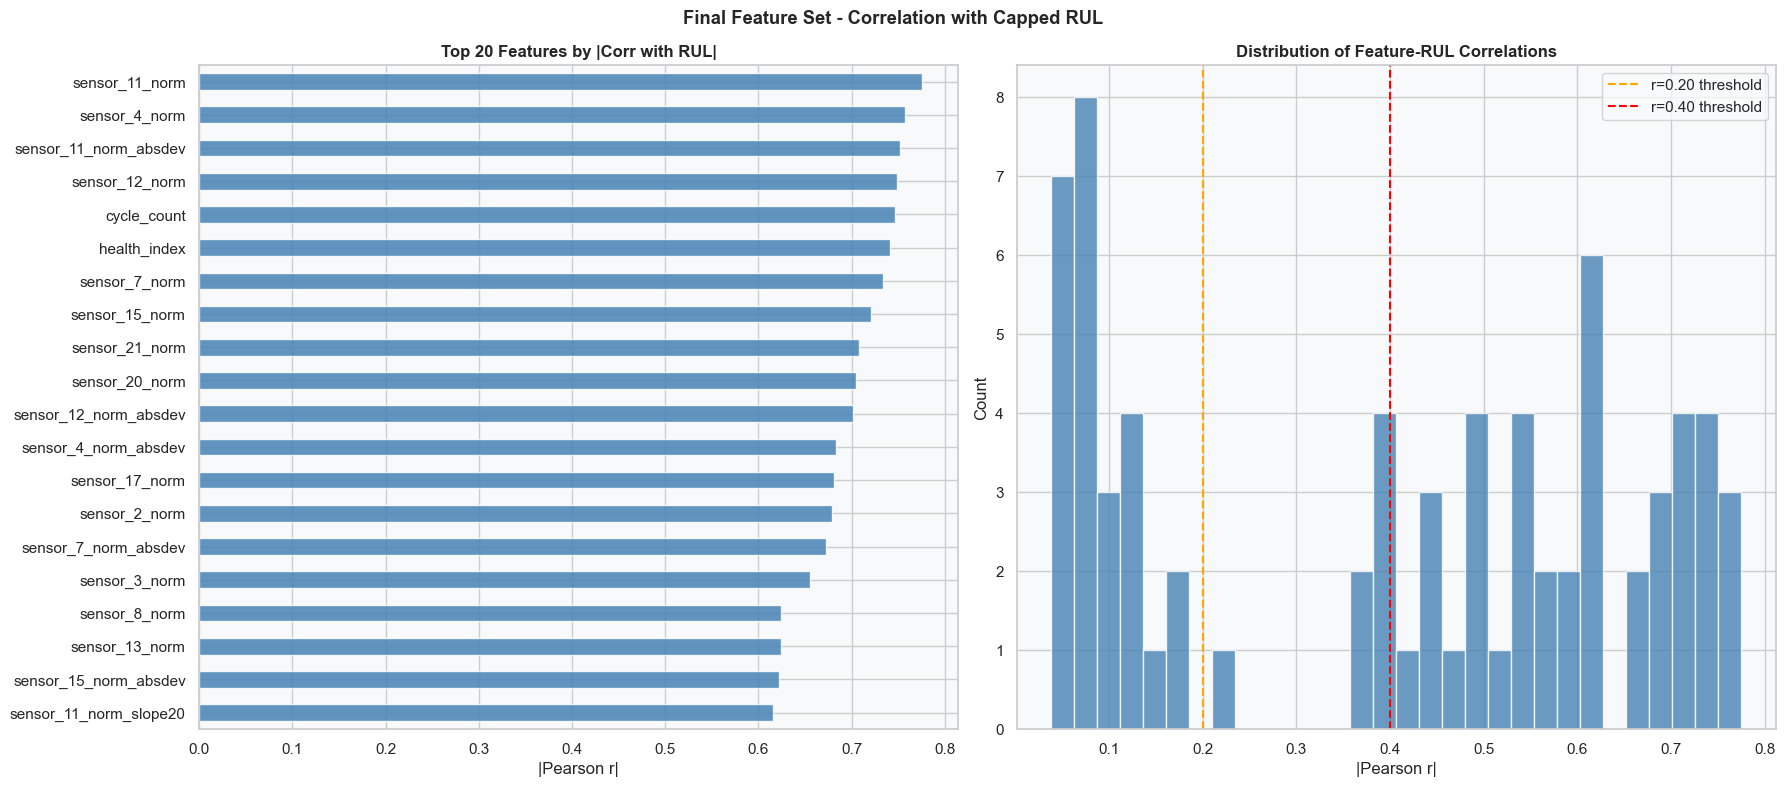

Features with |r| > 0.4 : 42
Features with |r| > 0.2 : 47
Features with |r| < 0.1 : 16


In [113]:
X_final = train_v9[ALL_FEATURE_COLS].copy()
rul_corr_final = X_final.corrwith(y_train).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Final Feature Set - Correlation with Capped RUL', fontweight='bold')

top20 = rul_corr_final.head(20)
colors_top = ['steelblue' if v > 0.4 else ('teal' if v > 0.2 else 'lightgray') for v in top20.values]
top20.plot(kind='barh', ax=axes[0], color=colors_top, alpha=0.85, edgecolor='white')
axes[0].set_title('Top 20 Features by |Corr with RUL|')
axes[0].set_xlabel('|Pearson r|')
axes[0].invert_yaxis()

axes[1].hist(rul_corr_final.values, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0.2, color='orange', linestyle='--', label='r=0.20 threshold')
axes[1].axvline(0.4, color='red',    linestyle='--', label='r=0.40 threshold')
axes[1].set_title('Distribution of Feature-RUL Correlations')
axes[1].set_xlabel('|Pearson r|'); axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Features with |r| > 0.4 : {(rul_corr_final > 0.4).sum()}')
print(f'Features with |r| > 0.2 : {(rul_corr_final > 0.2).sum()}')
print(f'Features with |r| < 0.1 : {(rul_corr_final < 0.1).sum()}')

### Key Findings

- **72 candidate features** survive into the final matrix after all engineering steps.
- **22 feature pairs** are highly correlated (|r| > 0.80), most involving `sensor_9`/`sensor_14` and their derived rolling/delta/slope variants - these sensors appear to be measuring closely related (or redundant) physical quantities.
- **42 features** correlate with capped RUL at |r| > 0.4, and only **16** fall below |r| = 0.1 - a healthy majority of the engineered matrix carries real predictive signal, though the redundant pairs identified above are good candidates for pruning or regularization (e.g., L1 penalties, tree-based feature importance) in the modeling notebook rather than dropping manually here.


---
## 12. Final Feature Matrix Export
Save the engineered feature matrices for direct use in model training notebooks

In [114]:
export_cols_train = ['engine_id','cycle'] + ALL_FEATURE_COLS + ['RUL_capped']
export_cols_train = [c for c in export_cols_train if c in train_v9.columns]

train_export = train_v9[export_cols_train].copy()
train_export.to_csv('data/transform/train_data.csv', index=False)

In [115]:
train_export.shape

(20631, 75)

---
## 13. Feature Extraction Pipeline

In [ ]:
class FeatureExtraction:
    def __init__(self, df):
        self.df = df.copy()
        
        self.DROP_COLS = ['sensor_1', 'sensor_10', 'sensor_19', 'sensor_18', 'op_set_3', 'sensor_16', 'sensor_5', 'op_set_2', 'sensor_6', 'op_set_1']
        self.FEATURE_COLUMNS = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
        self.KEY_SENSORS_NORM = [f'{col}_norm' for col in self.FEATURE_COLUMNS]
    
    def normalize_data(self, df, feature_cols, scaler, fit=False):
        df = df.copy()

        if fit:
            normed = scaler.fit_transform(df[feature_cols])
        else:
            normed = scaler.transform(df[feature_cols])

        normed = pd.DataFrame(
            normed,
            columns=[f'{col}_norm' for col in feature_cols],
            index=df.index
        )

        self.NORM_COLUMNS = normed.columns.to_list()

        return pd.concat([df, normed], axis=1)
    
    def add_rolling_features(self, df, feature_cols, window=15):
        df = df.sort_values(['engine_id','cycle']).copy()
        new_cols = {}

        for col in feature_cols:
            grp = df.groupby('engine_id')[col]
            roll = grp.rolling(window=window, min_periods=1)

            new_cols[f'{col}_rstd_{window}'] = roll.std().fillna(0).reset_index(level=0, drop=True)
        
        return pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

    def add_delta_features(self, df, feature_cols, lag=3):
        df = df.sort_values(['engine_id','cycle']).copy()
        new_cols = {}

        for col in feature_cols:
            shifted = df.groupby('engine_id')[col].shift(lag)
            shifted = shifted.groupby(df['engine_id']).transform(lambda x: x.bfill())

            new_cols[f'{col}_delta{lag}'] = df[col] - shifted

        return pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
    
    def __rolling_slope(self, series, window=20):
        n = len(series)
        slopes = np.full(n, np.nan)
        vals = series.values
        x = np.arange(window, dtype=float)
        x_mean = x.mean()
        x_var = ((x - x_mean) ** 2).sum()

        for i in range(window-1, n):
            y = vals[i - window + 1 : i + 1]
            slopes[i] = np.dot(x - x_mean, y - y.mean()) / x_var
        
        first_valid = next((i for i, v in enumerate(slopes) if not np.isnan(v)), 0)
        slopes[:first_valid] = slopes[first_valid] if first_valid < n else 0.0

        return pd.Series(slopes, index=series.index)
    
    def add_slope_features(self, df, feature_cols, window=20):
        df = df.sort_values(['engine_id','cycle']).copy()
        new_cols = {}

        for col in feature_cols:
            key = f'{col}_slope{window}'
            new_cols[key] = df.groupby('engine_id')[col].transform(lambda s: self.__rolling_slope(s, window))
        
        return pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
    
    def add_cycle_features(self, df):
        df = df.sort_values(['engine_id','cycle']).copy()
        df['cycle_count'] = df['cycle']
        
        return df

    def add_health_index(self, df, degrade_up, degrade_down):
        df = df.copy()
        up_contributions = 1.0 - df[degrade_up]
        down_contributions = df[degrade_down]

        all_contributions = pd.concat([up_contributions, down_contributions], axis=1)
        df['health_index'] = 1 - all_contributions.mean(axis=1)

        return df
    
    def add_baseline_deviations(self, df, feature_cols):
        df = df.sort_values(['engine_id','cycle']).copy()
        new_cols = {}

        eng_first = df.groupby('engine_id')[feature_cols].transform('first')

        for col in feature_cols:
            new_cols[f'{col}_absdev'] = (df[col] - eng_first[col]).abs()
        
        return pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
    
    def initiate_feature_extraction(self):
        DEGRADE_UP   = ['sensor_4_norm','sensor_11_norm','sensor_12_norm','sensor_15_norm','sensor_20_norm','sensor_21_norm']
        DEGRADE_DOWN = ['sensor_2_norm','sensor_3_norm','sensor_7_norm','sensor_8_norm','sensor_9_norm','sensor_13_norm','sensor_14_norm','sensor_17_norm']

        df = self.df.copy()

        final_df = df.pipe(self.normalize_data, self.FEATURE_COLUMNS, scaler).pipe(self.add_rolling_features, self.NORM_COLUMNS).pipe(self.add_delta_features, self.NORM_COLUMNS).pipe(self.add_slope_features, self.NORM_COLUMNS).pipe(self.add_cycle_features).pipe(self.add_health_index, degrade_down=DEGRADE_DOWN, degrade_up = DEGRADE_UP).pipe(self.add_baseline_deviations, self.NORM_COLUMNS)

        final_df.drop(self.DROP_COLS + self.FEATURE_COLUMNS, inplace=True, axis=1)

        return final_df

In [117]:
extractor = FeatureExtraction(test_raw)
test_final = extractor.initiate_feature_extraction()

test_final.head()

,engine_id,cycle,sensor_2_norm,sensor_3_norm,sensor_4_norm,sensor_7_norm,sensor_8_norm,sensor_9_norm,sensor_11_norm,sensor_12_norm,...,sensor_8_norm_absdev,sensor_9_norm_absdev,sensor_11_norm_absdev,sensor_12_norm_absdev,sensor_13_norm_absdev,sensor_14_norm_absdev,sensor_15_norm_absdev,sensor_17_norm_absdev,sensor_20_norm_absdev,sensor_21_norm_absdev
0,1,1,0.545181,0.310661,0.269413,0.652174,0.212121,0.127614,0.208333,0.646055,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,2,0.150602,0.379551,0.222316,0.805153,0.166667,0.146684,0.386905,0.739872,...,0.045455,0.019070,0.178571,0.093817,0.044118,0.072608,0.095806,0.083333,0.124031,0.024993
2,1,3,0.376506,0.346632,0.322248,0.685990,0.227273,0.158081,0.386905,0.699360,...,0.015152,0.030468,0.178571,0.053305,0.000000,0.023480,0.149673,0.083333,0.170543,0.059514
3,1,4,0.370482,0.285154,0.408001,0.679549,0.196970,0.105717,0.255952,0.573561,...,0.015152,0.021897,0.047619,0.072495,0.029412,0.037930,0.051943,0.083333,0.108527,0.000276
4,1,5,0.391566,0.352082,0.332039,0.694042,0.166667,0.102396,0.273810,0.737740,...,0.045455,0.025218,0.065476,0.091684,0.000000,0.020590,0.008080,0.166667,0.100775,0.054543


In [118]:
test_final.to_csv('data/transform/test_features.csv', index=False)
rul_true.to_csv('data/transform/test_rul.csv', index=False)

In [119]:
train_export['sensor_4_norm'].describe()

count    20631.000000
mean         0.450435
std          0.151935
min          0.000000
25%          0.339467
50%          0.435348
75%          0.545324
max          1.000000
Name: sensor_4_norm, dtype: float64

In [120]:
train_export[['engine_id','cycle','RUL_capped']].tail(20)

,engine_id,cycle,RUL_capped
20611,100,181,19
20612,100,182,18
20613,100,183,17
20614,100,184,16
20615,100,185,15
20616,100,186,14
20617,100,187,13
20618,100,188,12
20619,100,189,11
20620,100,190,10


---
## Summary

### Feature Engineering
Starting from the EDA's recommendations, the raw 26-column NASA-CMAPSS FD001 dataset was transformed into 75-column training matrix (and a matching test matrix) ready for modelling.

---
### 1. What was removed?
10 near-zero variance columns (7 constant sensors + all 3 operational settings, since FD001 runs under a single operating condition) - dead weight that added no signal.

---
### 2. What was Engineered?
- A capped, log-transformed RUL target that concentrates learning on the degradation zone instead of the unbounded raw cycle count.
- Engine Min-Max normalized sensors that remove manufacturing-baseline offsets.
- Rolling-std, delta and slope features that captures volatility, short-term movement and trend direction respectively.
- Cycle-position features encoding how far into its life an engine is.
- A single Health Index that compresses 14 sensors into one degradation score.
- Baseline-deviation features quantifying cumulative drift from each engine's own starting point.